### KNN clasifier 

Zastosowanie klasyfikatora Knn poprzedzamy odpowiednim załadowaniem danych. W Komórce ponizej dokonujemy selekcji cech,
na podstawie których klasyfikator bedzie decydowal czy sygnal w danym oknie jest z anomalią, zdecydowalismy się na 3 cechy:
- qSQI (Corelation signal quality index)
- cSQI (Quality signal quality index)
- kSQI (Kurtosis signal quality index)

##### qSQI
Metryka oceniająca wiarygodność sygnału poprzez porównanie wyników dwóch niezależnych algorytmów detekcji zespołów QRS

##### cSQI
Metryka oceniająca powtarzalność kształtu (morfologii) zespołów QRS w badanym oknie czasowym. 
Opiera się na założeniu, że zdrowe uderzenia serca u danego pacjenta wyglądają bardzo podobnie do siebie.

##### kSQI
Metryka statystyczna wykorzystująca czwarty moment centralny (kurtozę) do oceny rozkładu amplitud sygnału. Określa "szpilkowatość" wykresu.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix



data_dir = Path("dataset")

train_df = pd.read_pickle(data_dir / "dataset_train.pkl")
val_df = pd.read_pickle(data_dir / "dataset_val.pkl")

features = ['qSQI', 'cSQI', 'kurtosis']
targets = ['label']

X_train = train_df[features].values
y_train = train_df[targets].values.astype(int)

X_val = val_df[features].values
y_val = val_df[targets].values.astype(int)

#filing nan values with mean values 
imputer = SimpleImputer(strategy="mean")
X_train_im = imputer.fit_transform(X_train)
X_val_im = imputer.fit_transform(X_val)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_im)
X_val_scaled = scaler.fit_transform(X_val_im)

k = 17

knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train_scaled, y_train.ravel())

y_pred = knn.predict(X_val_scaled)

# Raport tekstowy
print(classification_report(y_val, y_pred, target_names=['Valid (0)', 'Anomally (1)']))


              precision    recall  f1-score   support

   Valid (0)       0.79      0.87      0.83        30
Anomally (1)       0.78      0.67      0.72        21

    accuracy                           0.78        51
   macro avg       0.78      0.77      0.77        51
weighted avg       0.78      0.78      0.78        51



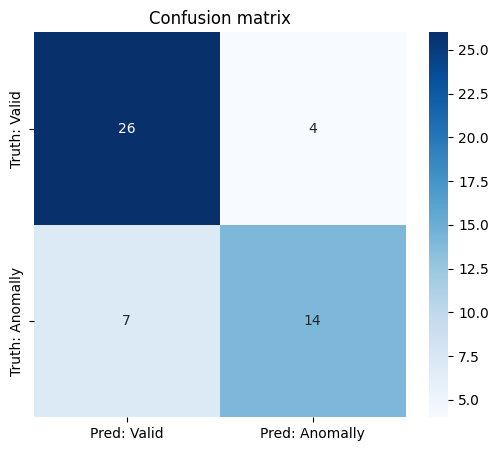

In [7]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Valid', 'Pred: Anomally'],
            yticklabels=['Truth: Valid', 'Truth: Anomally'])
plt.title('Confusion matrix')
plt.show()

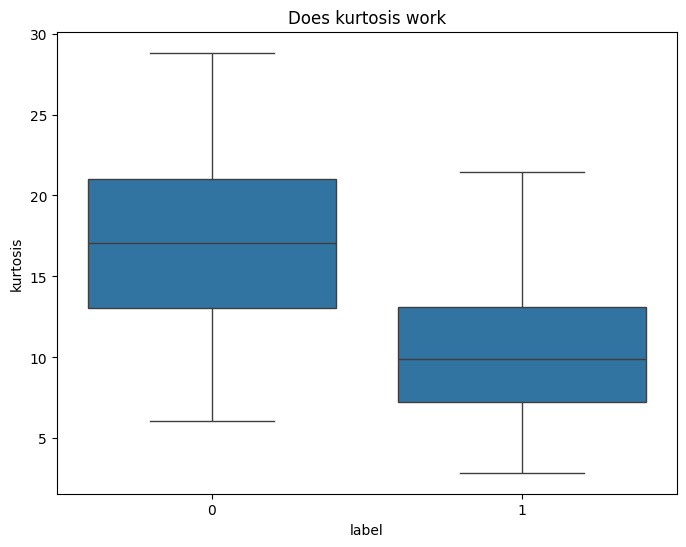

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.boxplot(x='label', y='kurtosis', data=train_df, showfliers=False) 
plt.title("Does kurtosis work")
plt.show()

### Wyszukiwanie najlepszych paramterow 

In [9]:
from sklearn.model_selection import GridSearchCV

knn_params = {'n_neighbors' : range(1, 20)}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')

knn_grid.fit(X_train_scaled, y_train.ravel())

best_k = knn_grid.best_params_['n_neighbors']
best_score = knn_grid.best_score_

print(f"best foudn k: {best_k}")
print(f"best found accuracy: {best_score}")



best foudn k: 17
best found accuracy: 0.7781707317073171


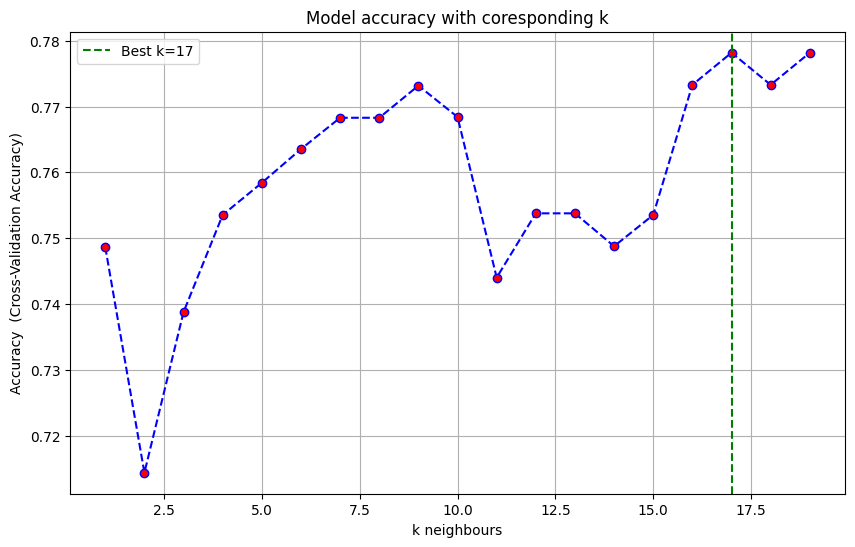

In [10]:
results = knn_grid.cv_results_['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), results, marker='o', linestyle='dashed', color='blue', markerfacecolor='red')
plt.title('Model accuracy with coresponding k')
plt.xlabel('k neighbours')
plt.ylabel('Accuracy  (Cross-Validation Accuracy)')
plt.axvline(best_k, color='green', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
best_knn = knn_grid.best_estimator_

print(f"final accuracy: {best_knn.score(X_val_scaled, y_val):.2%}")

y_pred = best_knn.predict(X_val_scaled)
print(classification_report(y_val, y_pred, target_names=['Valid (0)', 'Anomally (1)']))



final accuracy: 78.43%
              precision    recall  f1-score   support

   Valid (0)       0.79      0.87      0.83        30
Anomally (1)       0.78      0.67      0.72        21

    accuracy                           0.78        51
   macro avg       0.78      0.77      0.77        51
weighted avg       0.78      0.78      0.78        51



In [ ]:
lengths = train_df['sygnał'].apply(len)
print("Signal lenghts")
print(lengths.value_counts())



Występujące długości sygnałów:
sygnał
1280    203
Name: count, dtype: int64


In [23]:
def filter_lenght(df):
    df_filtered = df[df['sygnał'].apply(len) == 1280].copy()
    df_filtered.reset_index(drop=True, inplace=True)

    return df_filtered

In [24]:
train_df = filter_lenght(train_df)
val_df = filter_lenght(val_df)